# Pure CIFAR-10 VAE pretraining from scratch

This notebook deliberately contains no Lightning-Bolts weights, drift code, generator, or VQ-VAE code. It trains a residual convolutional VAE on all CIFAR-10 images and saves the best reconstruction checkpoint for later deer-only experiments.

The first experiment is a deterministic one-batch overfit test. Full training always reconstructs through the posterior mean (z = mu), so posterior sampling cannot blur the reconstruction. A tiny optional KL coefficient keeps the posterior heads usable for later latent-space work.

In [15]:
import pickle
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [16]:
def unpickle(file):
    with open(file, 'rb') as handle: return pickle.load(handle, encoding='bytes')

def find_cifar_directory():
    candidates = [Path('../image_gen/cifar-10-batches-py'), Path('../../image_gen/cifar-10-batches-py'), Path('image_gen/cifar-10-batches-py'), Path('cifar-10-batches-py')]
    for path in candidates:
        if path.exists(): return path
    raise FileNotFoundError('Could not find cifar-10-batches-py. Update the candidates above.')

CIFAR_DIR = find_cifar_directory()
image_batches, label_batches = [], []
for batch_index in range(1, 6):
    batch = unpickle(CIFAR_DIR / f'data_batch_{batch_index}')
    image_batches.append(batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1))
    label_batches.append(np.asarray(batch[b'labels']))
cifar_images = np.concatenate(image_batches, axis=0)
cifar_labels = np.concatenate(label_batches, axis=0)
deer_images = cifar_images[cifar_labels == 4]
print('CIFAR-10 images:', len(cifar_images), '| deer images:', len(deer_images))

class CIFARArrayDataset(Dataset):
    def __init__(self, images): self.images = images
    def __len__(self): return len(self.images)
    def __getitem__(self, index):
        return torch.from_numpy(self.images[index]).permute(2, 0, 1).float().div_(255.0)

batch_size = 64
pin_memory = torch.cuda.is_available()
full_dataset = CIFARArrayDataset(cifar_images)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0, pin_memory=pin_memory)
deer_loader = DataLoader(CIFARArrayDataset(deer_images), batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0, pin_memory=pin_memory)
print('train batches:', len(train_loader), '| validation batches:', len(val_loader), '| deer batches:', len(deer_loader))

C:\Users\mateo\AppData\Local\Temp\ipykernel_34900\3957158968.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  with open(file, 'rb') as handle: return pickle.load(handle, encoding='bytes')


CIFAR-10 images: 50000 | deer images: 5000
train batches: 703 | validation batches: 79 | deer batches: 79


In [23]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, groups=8):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(channels, channels, 3, padding=1), nn.GroupNorm(groups, channels), nn.SiLU(), nn.Conv2d(channels, channels, 3, padding=1), nn.GroupNorm(groups, channels))
        self.activation = nn.SiLU()
    def forward(self, x): return self.activation(x + self.block(x))

class Downsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__(); self.block = nn.Sequential(nn.Conv2d(in_channels, out_channels, 4, stride=2, padding=1), nn.GroupNorm(8, out_channels), nn.SiLU())
    def forward(self, x): return self.block(x)

class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__(); self.block = nn.Sequential(nn.ConvTranspose2d(in_channels, out_channels, 4, stride=2, padding=1), nn.GroupNorm(8, out_channels), nn.SiLU())
    def forward(self, x): return self.block(x)

class CIFARVAE(nn.Module):
    def __init__(self, latent_dim=128, logvar_min=-8.0, logvar_max=4.0):
        super().__init__(); self.latent_dim = latent_dim; self.logvar_min, self.logvar_max = logvar_min, logvar_max
        self.encoder = nn.Sequential(nn.Conv2d(3,64,3,padding=1), nn.GroupNorm(8,64), nn.SiLU(), ResidualBlock(64), Downsample(64,96), ResidualBlock(96), Downsample(96,160), ResidualBlock(160), Downsample(160,256), ResidualBlock(256), Downsample(256,256), ResidualBlock(256))
        self.fc_mu = nn.Linear(256*2*2, latent_dim); self.fc_logvar = nn.Linear(256*2*2, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, 256*2*2)
        self.decoder = nn.Sequential(ResidualBlock(256), Upsample(256,256), ResidualBlock(256), Upsample(256,160), ResidualBlock(160), Upsample(160,96), ResidualBlock(96), Upsample(96,64), ResidualBlock(64), nn.Conv2d(64,3,3,padding=1), nn.Sigmoid())
        self.apply(self._init_weights)
    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
            nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            if module.bias is not None: nn.init.zeros_(module.bias)
    def encode(self, x):
        features = self.encoder(x).flatten(start_dim=1); mu = self.fc_mu(features); logvar = self.fc_logvar(features).clamp(self.logvar_min, self.logvar_max)
        return mu, logvar
    def reparameterize(self, mu, logvar): return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
    def decode(self, z): return self.decoder(self.decoder_input(z).view(z.shape[0],256,2,2))
    def forward(self, x, sample=True):
        mu, logvar = self.encode(x); z = self.reparameterize(mu, logvar) if sample else mu
        return self.decode(z), mu, logvar, z

model = CIFARVAE(latent_dim=128).to(device)
print('parameters:', sum(parameter.numel() for parameter in model.parameters()), '| latent dimension:', model.latent_dim)

parameters: 10627587 | latent dimension: 128


In [24]:
def reconstruction_terms(reconstruction, target):
    mse = F.mse_loss(reconstruction, target); l1 = F.l1_loss(reconstruction, target)
    return 0.7*mse + 0.3*l1, mse, l1

def kl_loss(mu, logvar): return (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1)).mean()

def evaluate_reconstruction(model, loader, sample=False):
    model.eval(); totals = {'loss':0., 'mse':0., 'l1':0., 'kl':0.}; count = 0
    with torch.no_grad():
        for images in loader:
            images = images.to(device, non_blocking=True); reconstruction, mu, logvar, _ = model(images, sample=sample)
            loss, mse, l1 = reconstruction_terms(reconstruction, images)
            totals['loss'] += loss.item(); totals['mse'] += mse.item(); totals['l1'] += l1.item(); totals['kl'] += kl_loss(mu, logvar).item(); count += 1
    return {key:value/max(count,1) for key,value in totals.items()}

def plot_reconstructions(model, loader, title, num_images=8):
    model.eval(); images = next(iter(loader))[:num_images].to(device)
    with torch.no_grad(): reconstruction, _, _, _ = model(images, sample=False)
    real, pred = images.cpu(), reconstruction.cpu(); fig, axes = plt.subplots(2,num_images,figsize=(2*num_images,4))
    for i in range(num_images):
        axes[0,i].imshow(real[i].permute(1,2,0)); axes[1,i].imshow(pred[i].permute(1,2,0)); axes[0,i].axis('off'); axes[1,i].axis('off')
    axes[0,0].set_ylabel('Real',fontweight='bold'); axes[1,0].set_ylabel('Recon',fontweight='bold'); fig.suptitle(title); plt.tight_layout(); plt.show()

overfit step 0000: mse=0.090529
overfit step 0100: mse=0.006510
overfit step 0200: mse=0.001984
overfit step 0300: mse=0.000932
overfit step 0400: mse=0.000537
overfit step 0500: mse=0.000365
overfit step 0599: mse=0.000282


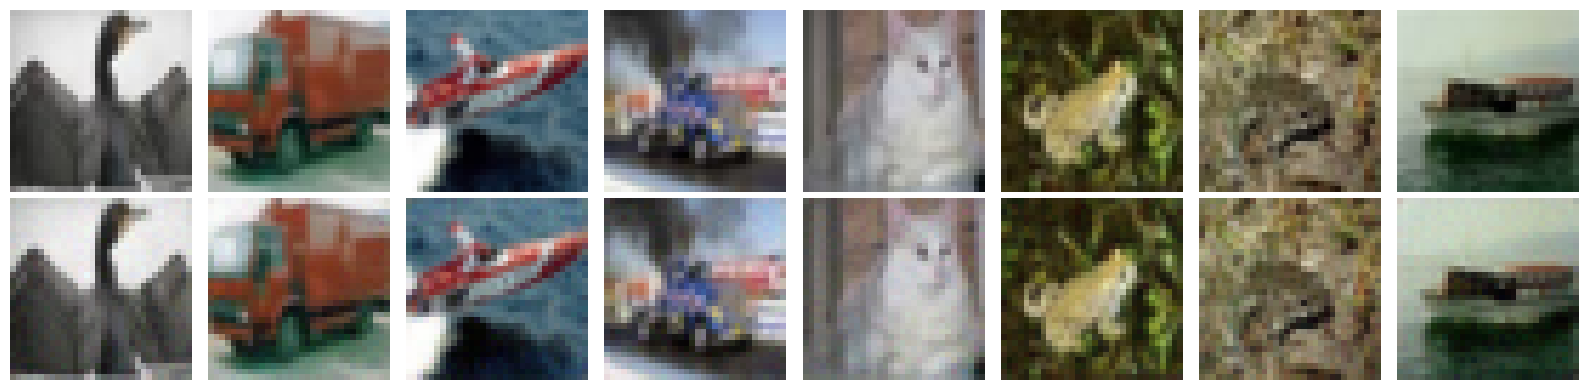

In [13]:
# A deterministic one-batch test must work before full training is trusted.
def deterministic_overfit_test(steps=600, batch_count=32, latent_dim=128):
    test_model = CIFARVAE(latent_dim=latent_dim).to(device); images = next(iter(train_loader))[:batch_count].to(device)
    optimizer = optim.Adam(test_model.parameters(), lr=2e-4); losses = []; test_model.train()
    for step in range(steps):
        reconstruction, _, _, _ = test_model(images, sample=False); loss = F.mse_loss(reconstruction, images)
        optimizer.zero_grad(set_to_none=True); loss.backward(); torch.nn.utils.clip_grad_norm_(test_model.parameters(), 1.0); optimizer.step(); losses.append(loss.item())
        if step % 100 == 0 or step == steps-1: print(f'overfit step {step:04d}: mse={loss.item():.6f}')
    test_model.eval()
    with torch.no_grad(): recon, _, _, _ = test_model(images, sample=False)
    fig, axes = plt.subplots(2,8,figsize=(16,4))
    for i in range(8):
        axes[0,i].imshow(images[i].cpu().permute(1,2,0)); axes[1,i].imshow(recon[i].cpu().permute(1,2,0)); axes[0,i].axis('off'); axes[1,i].axis('off')
    axes[0,0].set_ylabel('Real'); axes[1,0].set_ylabel('Overfit recon'); plt.tight_layout(); plt.show()
    return test_model, losses

overfit_model, overfit_losses = deterministic_overfit_test()

In [25]:
set_seed(42)
model = CIFARVAE(latent_dim=128).to(device)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
num_epochs = 200; scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=2e-5)
beta_final, kl_warmup_epochs = 1e-6, 50
history = {key:[] for key in ['train_loss','train_mse','train_l1','train_kl','val_loss','val_mse','val_l1','val_kl','beta']}
best_val_mse = float('inf'); best_state = None

epoch_iterator = tqdm(total=num_epochs * len(train_loader), desc='VAE training', unit='batch', mininterval=1.0, miniters=10)
for epoch in range(num_epochs):
    model.train(); running = {key:0. for key in ['loss','mse','l1','kl']}; beta = beta_final * min(1.0,(epoch+1)/kl_warmup_epochs)
    for batch_index, images in enumerate(train_loader):
        images = images.to(device, non_blocking=True); reconstruction, mu, logvar, _ = model(images, sample=False)
        reconstruction_loss, mse, l1 = reconstruction_terms(reconstruction, images); raw_kl = kl_loss(mu, logvar); loss = reconstruction_loss + beta*raw_kl
        if not torch.isfinite(loss): raise FloatingPointError(f'non-finite loss at epoch {epoch}, batch {batch_index}')
        optimizer.zero_grad(set_to_none=True); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        running['loss'] += loss.detach().item(); running['mse'] += mse.detach().item(); running['l1'] += l1.detach().item(); running['kl'] += raw_kl.detach().item()
        epoch_iterator.update(1); epoch_iterator.set_postfix(epoch=epoch + 1, loss=f'{loss.item():.4f}', mse=f'{mse.item():.4f}')
    train_metrics = {key:value/len(train_loader) for key,value in running.items()}; val_metrics = evaluate_reconstruction(model,val_loader,sample=False)
    for key in ['loss','mse','l1','kl']: history[f'train_{key}'].append(train_metrics[key]); history[f'val_{key}'].append(val_metrics[key])
    history['beta'].append(beta); scheduler.step()
    epoch_iterator.set_postfix(epoch=epoch + 1, beta=f'{beta:.1e}', train_mse=f'{train_metrics["mse"]:.4f}', val_mse=f'{val_metrics["mse"]:.4f}')
    if val_metrics['mse'] < best_val_mse:
        best_val_mse = val_metrics['mse']; best_state = {key:value.detach().cpu().clone() for key,value in model.state_dict().items()}
        torch.save({'model_state_dict':best_state,'latent_dim':model.latent_dim,'val_mse':best_val_mse,'epoch':epoch},'pure_vae_cifar10_best.pt')
    if epoch % 10 == 0 or epoch == num_epochs-1:
        print(f"epoch {epoch:03d}: beta={beta:.2e} deterministic=True train_mse={train_metrics['mse']:.6f} val_mse={val_metrics['mse']:.6f} raw_kl={train_metrics['kl']:.3f} weighted_kl={beta*train_metrics['kl']:.6f}")

model.load_state_dict(best_state); model.to(device); model.eval(); torch.save({'model_state_dict':model.state_dict(),'latent_dim':model.latent_dim,'val_mse':best_val_mse},'pure_vae_cifar10_best.pt')
epoch_iterator.close()
print('best validation MSE:', best_val_mse)

VAE training:   0%|          | 0/140600 [00:00<?, ?batch/s]

epoch 080: beta=1.00e-06 deterministic=True train_mse=0.003260 val_mse=0.004478 raw_kl=9.036 weighted_kl=0.000009
epoch 090: beta=1.00e-06 deterministic=True train_mse=0.003087 val_mse=0.004592 raw_kl=8.914 weighted_kl=0.000009


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



epoch 160: beta=1.00e-06 deterministic=True train_mse=0.002356 val_mse=0.005303 raw_kl=7.462 weighted_kl=0.000007
epoch 180: beta=1.00e-06 deterministic=True train_mse=0.002266 val_mse=0.005532 raw_kl=7.207 weighted_kl=0.000007
epoch 190: beta=1.00e-06 deterministic=True train_mse=0.002234 val_mse=0.005547 raw_kl=7.116 weighted_kl=0.000007


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



epoch 199: beta=1.00e-06 deterministic=True train_mse=0.002212 val_mse=0.005655 raw_kl=7.045 weighted_kl=0.000007
best validation MSE: 0.004287777017636956


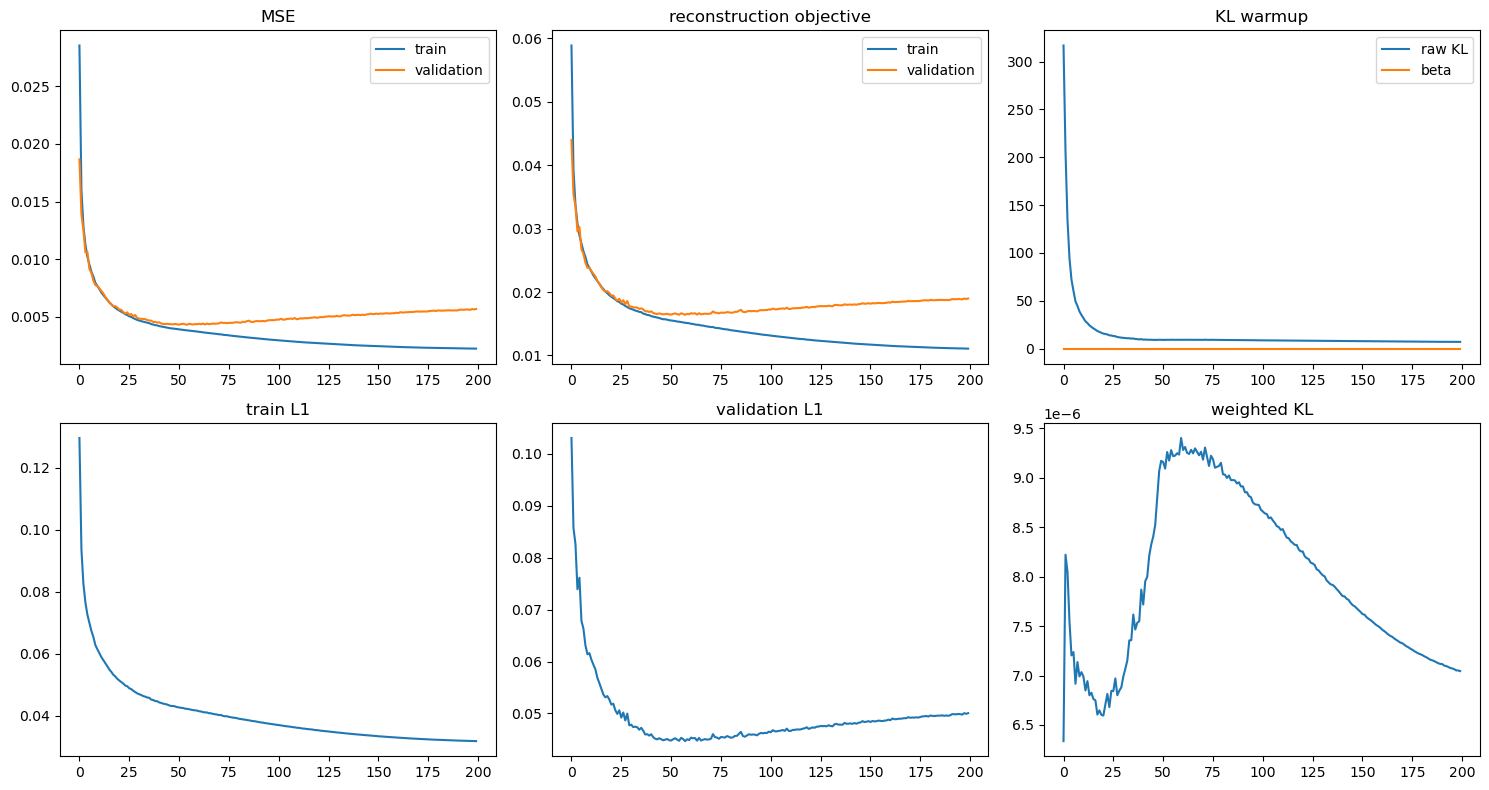

Validation metrics: {'loss': 0.016424787124689623, 'mse': 0.004287777017636956, 'l1': 0.04474447578003135, 'kl': 9.048174423507497}
Deer metrics: {'loss': 0.01424954665376793, 'mse': 0.0031849312377928555, 'l1': 0.04006698114585273, 'kl': 8.361962801293481}


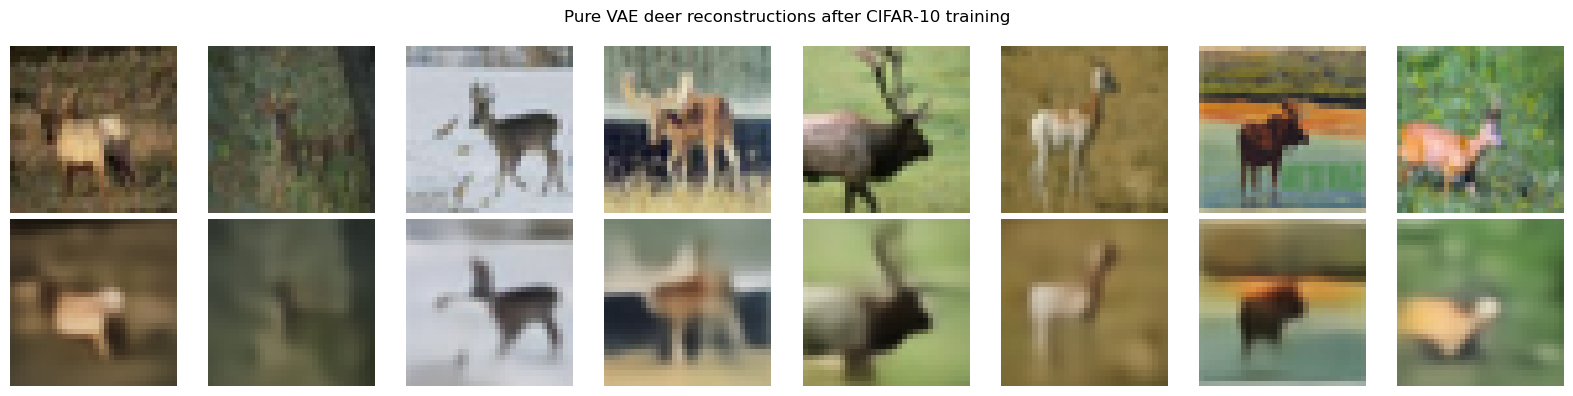

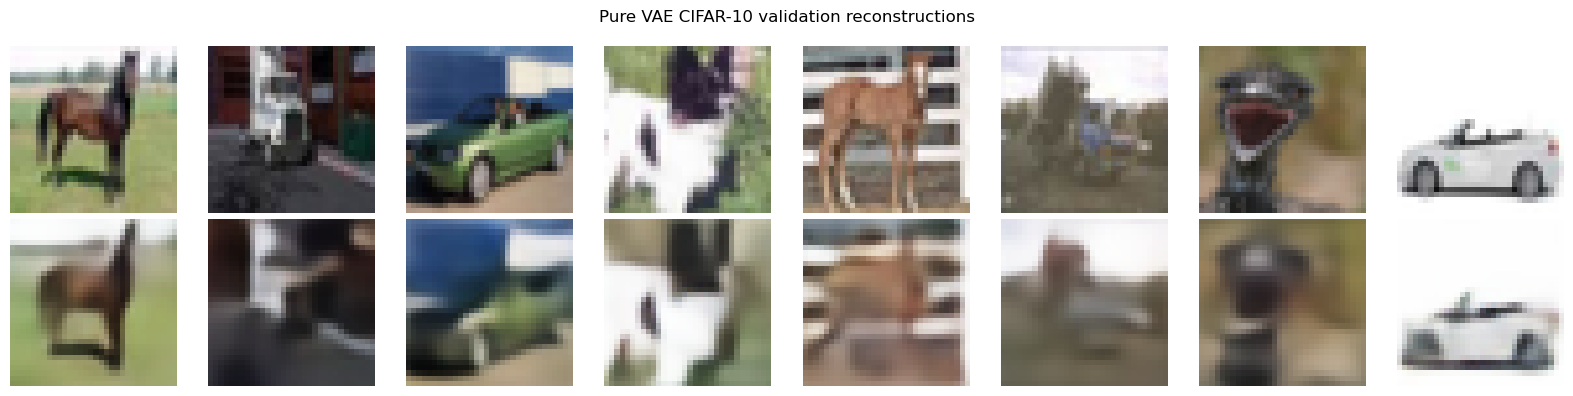

In [26]:
fig, axes = plt.subplots(2,3,figsize=(15,8))
axes[0,0].plot(history['train_mse'],label='train'); axes[0,0].plot(history['val_mse'],label='validation'); axes[0,0].set_title('MSE'); axes[0,0].legend()
axes[0,1].plot(history['train_loss'],label='train'); axes[0,1].plot(history['val_loss'],label='validation'); axes[0,1].set_title('reconstruction objective'); axes[0,1].legend()
axes[0,2].plot(history['train_kl'],label='raw KL'); axes[0,2].plot(history['beta'],label='beta'); axes[0,2].set_title('KL warmup'); axes[0,2].legend()
axes[1,0].plot(history['train_l1']); axes[1,0].set_title('train L1'); axes[1,1].plot(history['val_l1']); axes[1,1].set_title('validation L1'); axes[1,2].plot(np.array(history['train_kl'])*np.array(history['beta'])); axes[1,2].set_title('weighted KL')
plt.tight_layout(); plt.show()
print('Validation metrics:',evaluate_reconstruction(model,val_loader,sample=False)); print('Deer metrics:',evaluate_reconstruction(model,deer_loader,sample=False))
plot_reconstructions(model,deer_loader,'Pure VAE deer reconstructions after CIFAR-10 training')
plot_reconstructions(model,val_loader,'Pure VAE CIFAR-10 validation reconstructions')

deer posterior mean absolute value: 0.28223878145217896
deer posterior std mean: 0.9998066425323486
deer posterior std median: 0.999748945236206
active latent dimensions (std of mu > 0.05): 128


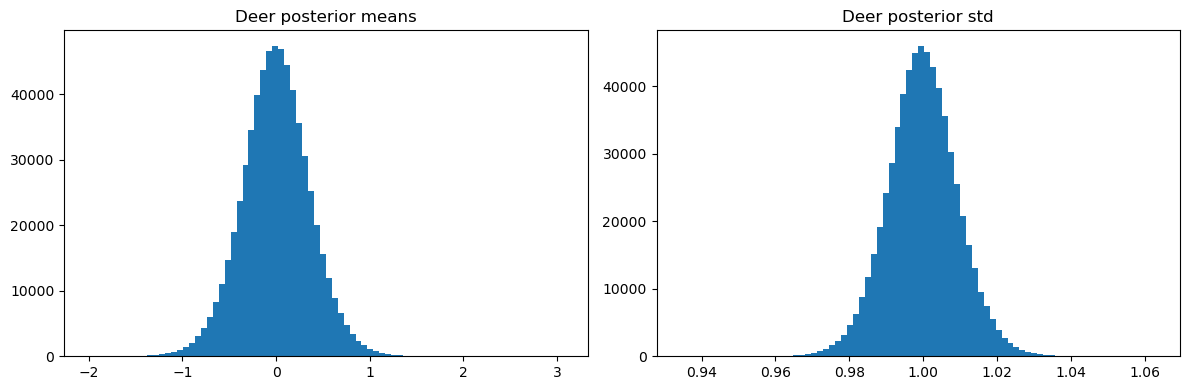

Saved checkpoint: pure_vae_cifar10_best.pt


In [27]:
model.eval(); all_mu, all_logvar = [], []
with torch.no_grad():
    for images in deer_loader:
        _, mu, logvar, _ = model(images.to(device), sample=False); all_mu.append(mu.cpu()); all_logvar.append(logvar.cpu())
mu = torch.cat(all_mu); logvar = torch.cat(all_logvar); posterior_std = torch.exp(0.5*logvar)
print('deer posterior mean absolute value:',mu.abs().mean().item())
print('deer posterior std mean:',posterior_std.mean().item())
print('deer posterior std median:',posterior_std.median().item())
print('active latent dimensions (std of mu > 0.05):',int((mu.std(0)>0.05).sum()))
fig, axes = plt.subplots(1,2,figsize=(12,4)); axes[0].hist(mu.flatten().numpy(),bins=80); axes[0].set_title('Deer posterior means'); axes[1].hist(posterior_std.flatten().numpy(),bins=80); axes[1].set_title('Deer posterior std'); plt.tight_layout(); plt.show()

def load_saved_vae(path='pure_vae_cifar10_best.pt'):
    checkpoint = torch.load(path, map_location=device)
    loaded = CIFARVAE(latent_dim=int(checkpoint.get('latent_dim', 128))).to(device)
    state = checkpoint.get('model_state_dict', checkpoint)
    loaded.load_state_dict(state); loaded.eval()
    return loaded

print('Saved checkpoint: pure_vae_cifar10_best.pt')